# NATURAL LANGUAGE INFERENCE: USING ATTENTION

 In this section, we will describe and implement this attention-based method (with MLPs) for natural language inference.

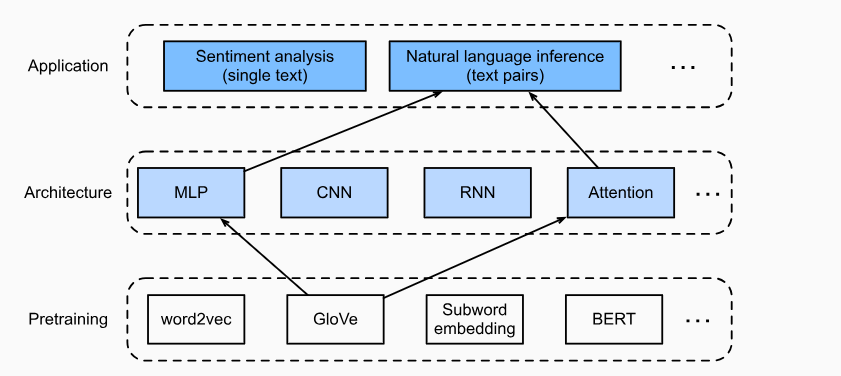

## 1. The Model

Simpler than preserving the order of tokens in premises and hypotheses, we can just align tokens in one text sequence to every token in the other, and vice versa, then compare and aggregate such information to predict the logical relationships between premises and hypotheses. Similar to alignment of tokens between source and target sentences in machine translation, the alignment of tokens between premises and hypotheses can be neatly accomplished by attention mechanisms.

At a high level, it consists of three jointly trained steps: attending, comparing, and aggregating. We will illustrate them step by step in the following.

In [1]:
import torch
from torch import nn
import sys
sys.path.append('/kaggle/input/main-dataset')
import spy
from torch.nn import functional as F

### 1.1. Attending

The first step is to align tokens in one text sequence to each token in the other sequence. Suppose that the premise is “i do need sleep” and the hypothesis is “i am tired”. Due to semantical similarity, we may wish to align “i” in the hypothesis with “i” in the premise, and align “tired” in the hypothesis with “sleep” in the premise. Likewise, we may wish to align “i” in the premise with “i” in the hypothesis, and align “need” and “sleep” in the premise with “tired” in the hypothesis. Note that such alignment is soft using weighted average, where ideally large weights are associated with the tokens to be aligned.

Now we describe the soft alignment using attention mechanisms in more detail. Denote by $A = (a_1, a_2,...,a_m)$ and 
$B = (b_1, b_2,...,b_m)$ the premise and hypothesis, whose number of tokens are 
$m$ and $n$, respectively, where 
$a_i, b_j \in \mathbb{R}^d$ ($i = 1,...,m,j=1,...,n$) is a $d$-dimensional word vector. For soft alignment, we compute the attention weights 
 as:

$$e_{ij} = f(a_i)^Tf(b_j)$$

where the function 
$f$ is an MLP defined in the following `mlp` function. The output dimension of 
 is specified by the `num_hiddens` argument of `mlp`.

In [2]:
def mlp(num_inputs, num_hiddens, flatten):
    net = []
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)

It should be highlighted that, in $f$ takes inputs 
$a_i$ and $b_j$ separately rather than takes a pair of them together as input. This decomposition trick leads to only $m + n$
 applications (linear complexity) of $f$
 rather than $mn$
 applications (quadratic complexity).

Normalizing the attention weights, we compute the weighted average of all the token vectors in the hypothesis to obtain representation of the hypothesis that is softly aligned with the token indexed by 
$i$ in the premise:

$$\boldsymbol{\beta}_i
=
\sum_{j=1}^{n}
\frac{\exp(e_{ij})}
     {\sum_{k=1}^{n} \exp(e_{ik})}
\, \mathbf{b}_j$$

Likewise, we compute soft alignment of premise tokens for each token indexed by $j$ in the hypothesis:

$$\boldsymbol{\alpha}_j
=
\sum_{i=1}^{m}
\frac{\exp(e_{ij})}
     {\sum_{k=1}^{m} \exp(e_{kj})}
\, \mathbf{a}_i$$

Below we define the `Attend` class to compute the soft alignment of hypotheses (`beta`) with input premises A and soft alignment of premises (`alpha`) with input hypotheses B.

In [3]:
class Attend(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super().__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)


    def forward(self, A, B):
        # f_A, f_B shape: (batch_size, num_tokens, num_hiddens)
        f_A = self.f(A)
        f_B = self.f(B)
        # e shape: (batch_size, num_tokens_A, num_tokens_B)
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))
        beta = torch.bmm(F.softmax(e, dim=-1), B)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)
        return beta, alpha

### 1.2. Comparing

In the next step, we compare a token in one sequence with the other sequence that is softly aligned with that token. Note that in soft alignment, all the tokens from one sequence, though with probably different attention weights, will be compared with a token in the other sequence. For example, suppose that the attending step determines that “need” and “sleep” in the premise are both aligned with “tired” in the hypothesis, the pair “tired–need sleep” will be compared.


In the comparing step, we feed the concatenation (operator `[.,.]`) of tokens from one sequence and aligned tokens from the other sequence into a function $g$ (an MLP):
$$v_{A, i} = g([a_i, \beta_i]), i = 1,2,...,m$$
$$v_{B, j} = g([b_j, \alpha_j]), j = 1,2,...,n$$

$v_{A, i}$ is the comparison between token 
$i$ in the premise and all the hypothesis tokens that are softly aligned with token 
$i$; while $v_{B, j}$ 
 is the comparison between token 
$j$ in the hypothesis and all the premise tokens that are softly aligned with token 
$j$. The following `Compare` class defines such as comparing step.

In [4]:
class Compare(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super().__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)


    def forward(self, A, B, beta, alpha):
        V_A = self.g(torch.cat((A, beta), dim=-1))
        V_B = self.g(torch.cat((B, alpha), dim=-1))
        return V_A, V_B

### 1.3. Aggregating

With two sets of comparison vectors 
$v_{A, i}$ ($i = 1,2,...,m$) and $v_{B, j}$ ($j = 1,2,...,n$) on hand, in the last step we will aggregate such information to infer the logical relationship. We begin by summing up both sets:
$$ v_A = \sum_{i=1}^{m}v_{A, i}, \quad v_B = \sum_{j=1}^{n}v_{B, j}$$

Next we feed the concatenation of both summarization results into function 
$h$ (an MLP) to obtain the classification result of the logical relationship:
$$\hat{y} = h([v_A, v_B])$$

The aggregation step is defined in the following `Aggregate` class.



In [5]:
class Aggregate(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super().__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = nn.Linear(num_hiddens, num_outputs)


    def forward(self, V_A, V_B):
        V_A = V_A.sum(dim=1)
        V_B = V_B.sum(dim=1)
        return self.linear(self.h(torch.cat((V_A, V_B), dim=-1)))

### 1.4. Putting it all together

By putting the attending, comparing, and aggregating steps together, we define the decomposable attention model to jointly train these three steps.



In [6]:
class DecomposableAttention(nn.Module):
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)


    def forward(self, X):
        premises, hypothesis = X
        A = self.embedding(premises)
        B = self.embedding(hypothesis)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        return self.aggregate(V_A, V_B)

## 2. Training and evaluating the model

### 2.1. Reading the dataset

Now we will train and evaluate the defined decomposable attention model on the SNLI dataset. We begin by reading the dataset.



In [7]:
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = spy.load_data_snli(batch_size, num_steps)

Processing SNLI dataset: 100%|██████████| 10000/10000 [00:00<00:00, 70254.23it/s]


### 2.2. Creating the model

We use the pretrained 100-dimensional GloVe embedding to represent the input tokens. Thus, we predefine the dimension of vectors 
$a_i$ and 
$b_j$ as 100. The output dimension of functions 
$f$ and 
$g$ is set to 200. Then we create a model instance, initialize its parameters, and load the GloVe embedding to initialize vectors of input tokens.

In [8]:
embed_size, num_hiddens, devices = 100, 200, spy.try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = spy.TokenEmbedding('http://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)

tensor([[ 0.3847,  0.4935,  0.4910,  ...,  0.0263,  0.3905,  0.5222],
        [-0.6610, -0.0730,  0.9238,  ..., -0.2256,  0.8148, -0.4405],
        [ 0.9747,  1.2276,  0.4538,  ...,  0.2209,  1.7439, -0.8991],
        ...,
        [-0.0205, -0.4512,  0.6993,  ...,  0.0381,  0.2786,  0.2889],
        [-0.2484, -0.2568,  0.0255,  ...,  0.2161, -0.3413,  0.6266],
        [-0.1438,  0.8681, -0.7219,  ...,  0.0553, -0.4339,  0.3486]])

### 2.3. Training and evaluating the model

Train loss: 0.495
Train acc: 0.805
Test acc: 0.827


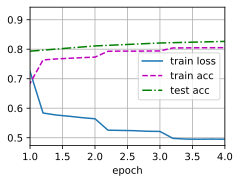

In [9]:
lr, num_epochs = 0.001, 4
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
spy.train(net, train_iter, test_iter, loss, trainer, num_epochs, devices=spy.try_all_gpus())

### 2.4. Using the model

Finally, define the prediction function to output the logical relationship between a pair of premise and hypothesis.



In [10]:
def predict_snli(net, vocab, premise, hypothesis):
    """Predict the logical relationship between the premise and the hypothesis"""
    net.eval()
    premise = torch.tensor(vocab[premise], 
                           device = 'cuda' if torch.cuda.is_available() else 'cpu')
    hypothesis = torch.tensor(vocab[hypothesis],
                              device = 'cuda' if torch.cuda.is_available() else 'cpu')
    label = torch.argmax(net([
        premise.reshape(1, -1), hypothesis.reshape(1, -1)]), dim=-1)
    return 'entailment' if label == 0 else 'contradiction' if label == 1 else 'neutral'

We can use the trained model to obtain the natural language inference result for a sample pair of sentences.



In [11]:
predict_snli(net, vocab, ['he', 'is', 'good', '.'], ['he', 'is', 'bad', '.'])

'contradiction'

In [14]:
predict_snli(net, vocab, ['A', 'man', 'is', 'running', 'the', 'coding', 'example', 'from', 'Dive', 'into', 'Deep', 'Learning', '.'], 
             ['The', 'man', 'is', 'awake', '.'])

'entailment'

In [13]:
predict_snli(net, vocab, ['The', 'musicians', 'are', 'performing', 'for', 'us', '.'], 
             ['The', 'musicians', 'are', 'famous', '.'])

'neutral'